<a href="https://colab.research.google.com/github/Tanishqnarayan/AIML/blob/main/AIML_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Load the Diabetes dataset
data = load_diabetes(as_frame=True)
df = data.frame

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
# Select only independent features
X = df.drop(columns=["target"])

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Scaled data shape:", X_scaled.shape)

Original number of samples: 442
Number of features: 10
Scaled data shape: (442, 10)


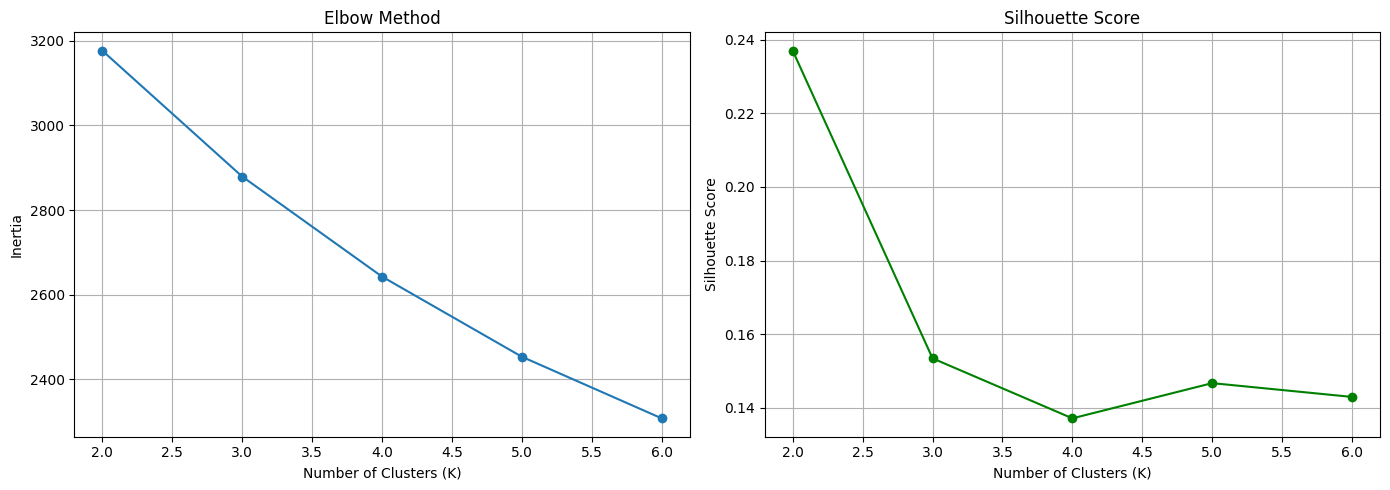

In [ ]:
inertia_values = []
silhouette_values = []
k_values = range(2, 7)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertia_values.append(model.inertia_)
    silhouette_values.append(
        silhouette_score(X_scaled, labels)
    )

# Plot both evaluation metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    list(k_values), inertia_values,
    marker="o"
)
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True)

axes[1].plot(
    list(k_values), silhouette_values,
    marker="o",
    color="green"
)
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
best_k = list(k_values)[np.argmax(silhouette_values)]

print("Selected number of clusters:", best_k)

# Train the final K-Means model
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster assignments to a copy of the dataset
clustered_df = df.copy()
clustered_df["Cluster"] = cluster_labels

print("\nCluster assignments:")
display(clustered_df.head(10))

print("\nNumber of samples in each cluster:")
print(clustered_df["Cluster"].value_counts().sort_index())

print("\nFinal silhouette score:",
      round(silhouette_score(X_scaled, cluster_labels), 4))

Selected number of clusters: 2

Cluster assignments:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target,Cluster
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0,1
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0,0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0,1
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0,1
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0,0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0,0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0,0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0,1
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0,1
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0,0



Number of samples in each cluster:
Cluster
0    214
1    228
Name: count, dtype: int64

Final silhouette score: 0.237


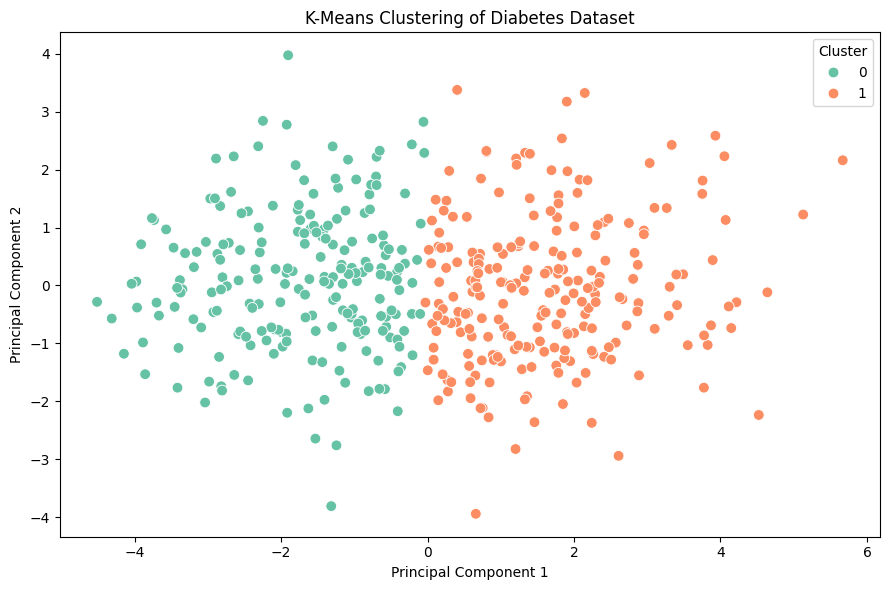

Variance explained by two components: 55.17 %


In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": cluster_labels
})

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=60
)

plt.title("K-Means Clustering of Diabetes Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

print("Variance explained by two components:",
      round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

In [ ]:
# Exclude target and calculate mean feature values
cluster_profiles = clustered_df.groupby("Cluster")[
    X.columns
].mean()

display(cluster_profiles.round(3))

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
Cluster,,,,,,,,,,
0,-0.018,-0.016,-0.025,-0.022,-0.026,-0.028,0.026,-0.036,-0.032,-0.026
1,0.017,0.015,0.024,0.021,0.024,0.026,-0.025,0.033,0.030,0.025


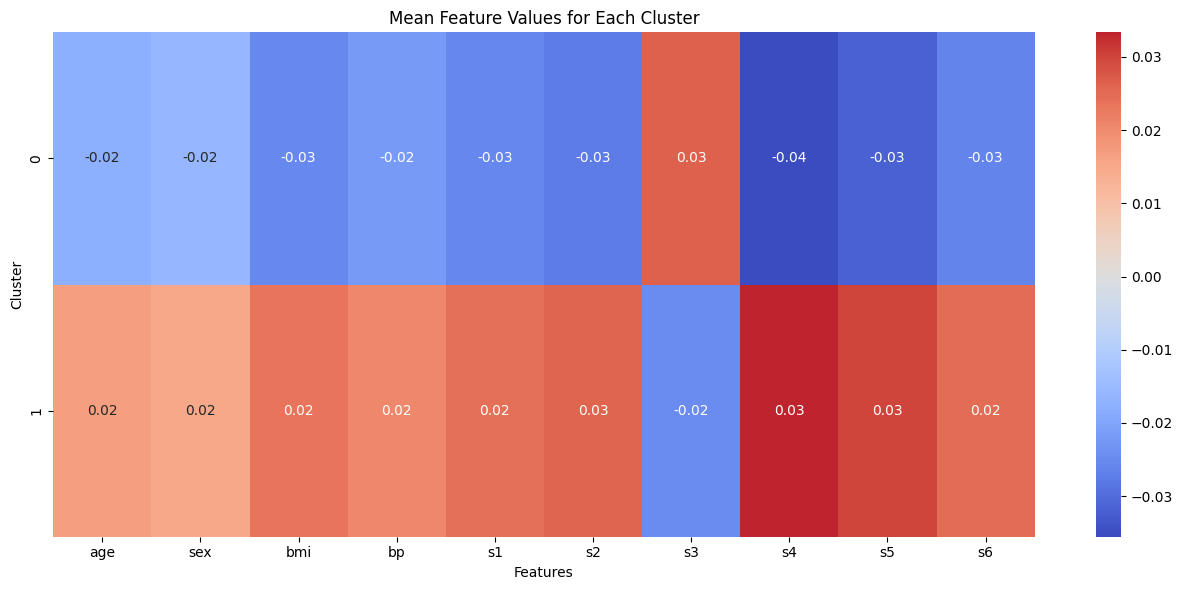

In [ ]:
plt.figure(figsize=(13, 6))

sns.heatmap(
    cluster_profiles,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Mean Feature Values for Each Cluster")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

In [ ]:
import os
import shutil
from google.colab import files

folder = "Assignment_2_Results"
os.makedirs(folder, exist_ok=True)

# Save cluster assignments
clustered_df.to_csv(
    f"{folder}/clustered_diabetes_data.csv",
    index=False
)

# Save cluster profiles
cluster_profiles.to_csv(
    f"{folder}/cluster_profiles.csv"
)

# Save evaluation results
evaluation = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_values,
    "Silhouette Score": silhouette_values
})

evaluation.to_csv(
    f"{folder}/cluster_evaluation.csv",
    index=False
)

# Save the PCA visualization
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=60
)
plt.title("K-Means Clustering of Diabetes Dataset")
plt.tight_layout()
plt.savefig(
    f"{folder}/pca_clusters.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# Save the cluster profile heatmap
plt.figure(figsize=(13, 6))
sns.heatmap(
    cluster_profiles,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Mean Feature Values for Each Cluster")
plt.tight_layout()
plt.savefig(
    f"{folder}/cluster_profiles.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# Save elbow and silhouette plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_values), inertia_values, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].grid(True)

axes[1].plot(list(k_values), silhouette_values, marker="o")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")
axes[1].grid(True)

plt.tight_layout()
plt.savefig(
    f"{folder}/cluster_evaluation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# Create ZIP archive
zip_path = shutil.make_archive(
    "Assignment_2_Complete_Results",
    "zip",
    folder
)

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>